Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/sovitrath/diabetic-retinopathy-2015-data-colored-resized
License(s): CC0-1.0
diabetic-retinopathy-2015-data-colored-resized.zip: Skipping, found more recently modified local copy (use --force to force download)
total 2.0G
-rw-r--r-- 1 root root 2.0G Mar  5  2020 diabetic-retinopathy-2015-data-colored-resized.zip
replace /content/kaggle_dataset/colored_images/colored_images/Mild/10030_left.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
/content/kaggle_dataset/trainLabels.csv
📁 /content/kaggle_dataset
   📄 trainLabels.csv
📁 /content/kaggle_dataset/colored_images
📁 /content/kaggle_dataset/colored_images/colored_images
No_DR: 25810 images
Sample images: ['2441_left.png', '35714_left.png', '26678_right.png', '35116_right.png', '6855_right.png']

Severe: 873 images
Sample images: ['19522_right.png', '18450_left.png', '40405_left.png', '31426_left.png', '3192_left.png']

Mild: 2443 images
Sample images: ['26811_r

No_DR Train:   0%|          | 0/20648 [00:00<?, ?it/s]

No_DR Test:   0%|          | 0/5162 [00:00<?, ?it/s]


Mild
Total : 2443
Train : 1954
Test  : 489


Mild Train:   0%|          | 0/1954 [00:00<?, ?it/s]

...

Moderate Test:   0%|          | 0/1059 [00:00<?, ?it/s]


Severe
Total : 873
Train : 698
Test  : 175


Severe Train:   0%|          | 0/698 [00:00<?, ?it/s]

Severe Test:   0%|          | 0/175 [00:00<?, ?it/s]


✅ 80/20 split and resizing completed!
Image: 2441_left.png
Shape: (224, 224, 3)
Minimum: 0.0
Maximum: 1.0
Shape: (224, 224, 3)
📁 /content/DR_dataset
📁 /content/DR_dataset/test
📁 /content/DR_dataset/test/No_DR
📁 /content/DR_dataset/test/Severe
📁 /content/DR_dataset/test/Mild
📁 /content/DR_dataset/test/Moderate
📁 /content/DR_dataset/train
📁 /content/DR_dataset/train/No_DR
📁 /content/DR_dataset/train/Severe
📁 /content/DR_dataset/train/Mild
📁 /content/DR_dataset/train/Moderate

===== TRAIN =====
No_DR: 20648 images
Mild: 1954 images
Moderate: 4233 images
Severe: 698 images

===== TEST =====
No_DR: 5162 images
Mild: 489 images
Moderate: 1059 images
Severe: 175 images


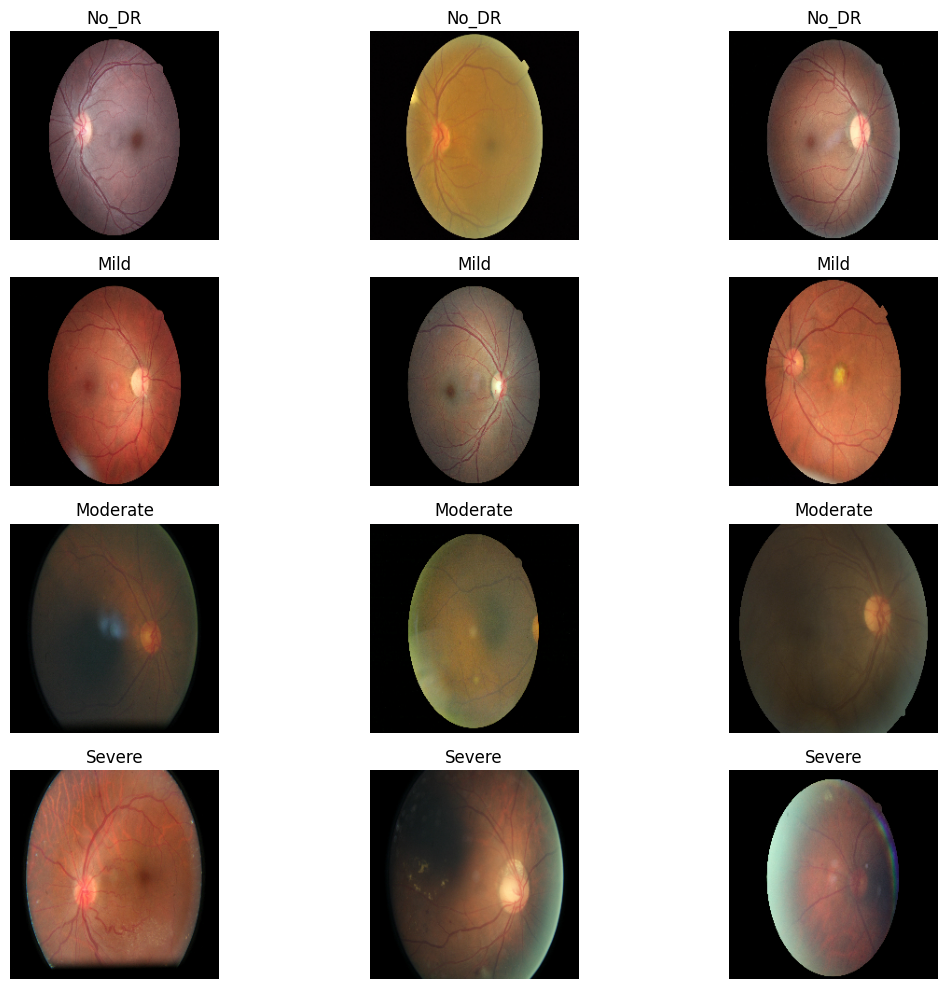

2.0G	/content/DR_dataset
34418


In [2]:
!pip install -q kaggle
from google.colab import files

uploaded = files.upload()
!mkdir -p /root/.kaggle
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json
!mkdir -p /content/kaggle_data

!kaggle datasets download \
    -d sovitrath/diabetic-retinopathy-2015-data-colored-resized \
    -p /content/kaggle_data
!ls -lh /content/kaggle_data
!mkdir -p /content/kaggle_dataset

!unzip -q /content/kaggle_data/*.zip -d /content/kaggle_dataset
!find /content/kaggle_dataset -maxdepth 3 -type f | head -30
import os

for root, dirs, files in os.walk("/content/kaggle_dataset"):
    level = root.replace("/content/kaggle_dataset", "").count(os.sep)

    if level <= 2:
        print("📁", root)
        for file in files[:10]:
            print("   📄", file)
import os

DATASET_PATH = "/content/kaggle_dataset/colored_images/colored_images"

for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)

    if os.path.isdir(folder_path):
        images = os.listdir(folder_path)
        print(f"{folder}: {len(images)} images")
        print("Sample images:", images[:5])
        print()
import os
import cv2
import shutil
import random
from pathlib import Path
from tqdm.auto import tqdm
SOURCE_DIR = Path("/content/kaggle_dataset/colored_images/colored_images")
OUTPUT_DIR = Path("/content/DR_dataset")

CLASSES = ["No_DR", "Mild", "Moderate", "Severe"]

IMG_SIZE = (224, 224)
TEST_SIZE = 0.20
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
for split in ["train", "test"]:
    for class_name in CLASSES:
        (OUTPUT_DIR / split / class_name).mkdir(
            parents=True,
            exist_ok=True
        )

print("✅ Train/Test folders created!")
for class_name in CLASSES:

    source_folder = SOURCE_DIR / class_name

    images = [
        f for f in source_folder.iterdir()
        if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]

    random.shuffle(images)

    split_index = int(len(images) * 0.80)

    train_images = images[:split_index]
    test_images = images[split_index:]

    print(f"\n{class_name}")
    print("Total :", len(images))
    print("Train :", len(train_images))
    print("Test  :", len(test_images))

    # Process training images
    for image_path in tqdm(train_images, desc=f"{class_name} Train"):

        img = cv2.imread(str(image_path))

        if img is None:
            continue

        img = cv2.resize(img, IMG_SIZE)

        destination = OUTPUT_DIR / "train" / class_name / image_path.name

        cv2.imwrite(str(destination), img)

    # Process testing images
    for image_path in tqdm(test_images, desc=f"{class_name} Test"):

        img = cv2.imread(str(image_path))

        if img is None:
            continue

        img = cv2.resize(img, IMG_SIZE)

        destination = OUTPUT_DIR / "test" / class_name / image_path.name

        cv2.imwrite(str(destination), img)

print("\n✅ 80/20 split and resizing completed!")
sample_folder = OUTPUT_DIR / "train" / "No_DR"

sample_image = next(sample_folder.glob("*"))

img = cv2.imread(str(sample_image))

print("Image:", sample_image.name)
print("Shape:", img.shape)
img_normalized = img.astype("float32") / 255.0

print("Minimum:", img_normalized.min())
print("Maximum:", img_normalized.max())
print("Shape:", img_normalized.shape)
import os

for root, dirs, files in os.walk("/content/DR_dataset"):
    level = root.replace("/content/DR_dataset", "").count(os.sep)

    if level <= 2:
        print("📁", root)
from pathlib import Path

for split in ["train", "test"]:
    print(f"\n===== {split.upper()} =====")

    for cls in ["No_DR", "Mild", "Moderate", "Severe"]:
        folder = Path(f"/content/DR_dataset/{split}/{cls}")
        count = len(list(folder.glob("*")))
        print(f"{cls}: {count} images")
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

classes = ["No_DR", "Mild", "Moderate", "Severe"]

plt.figure(figsize=(12, 10))

plot_number = 1

for cls in classes:
    folder = Path(f"/content/DR_dataset/train/{cls}")
    images = list(folder.glob("*"))[:3]

    for image_path in images:
        img = Image.open(image_path)

        plt.subplot(4, 3, plot_number)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

        plot_number += 1

plt.tight_layout()
plt.show()
!du -sh /content/DR_dataset
!find /content/DR_dataset -type f | wc -l





